# Importing the libraries

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action = 'ignore')
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load the dataset

In [80]:
data = pd.read_csv('drug - drug.csv')

In [82]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [84]:
data.shape

(200, 6)

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


# Encode categorical features to numeric values

In [88]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['BP'] = le.fit_transform(data['BP'])
data['Cholesterol'] = le.fit_transform(data['Cholesterol'])
data['Drug'] = le.fit_transform(data['Drug'])

# Define features (X) and target variable (y)

In [90]:
X = data.drop('Drug', axis=1)
y = data['Drug']

In [92]:
X

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [94]:
y

0      4
1      2
2      2
3      3
4      4
      ..
195    2
196    2
197    3
198    3
199    3
Name: Drug, Length: 200, dtype: int32

# Split the dataset into training and testing sets (70% training, 30% testing)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

# Create and train the Decision Tree classifier with 'entropy' as the criterion

In [98]:
dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

# Make predictions and calculate accuracy

In [100]:
y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [102]:
print(f'Accuracy of the Decision Tree: {accuracy * 100:.2f}%')

Accuracy of the Decision Tree: 100.00%


# Visualisation

In [104]:
from sklearn.tree import plot_tree

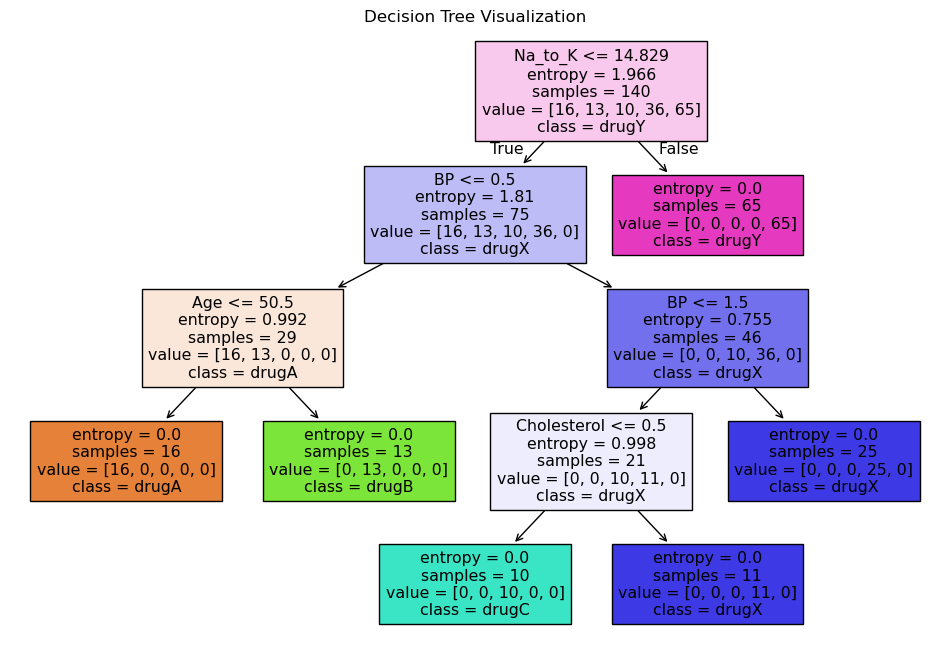

In [108]:
# Get class names from the label encoder (the original labels)
class_names = le.inverse_transform(sorted(y.unique()))

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    dt_classifier,
    feature_names=X.columns,
    class_names=class_names,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

# Confusion Matrix

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

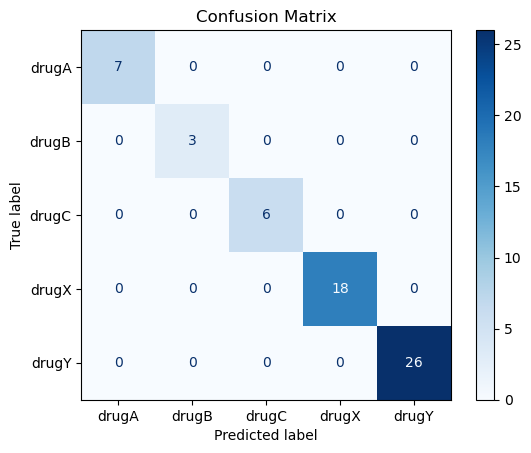

In [112]:
unique_labels = le.inverse_transform(sorted(y.unique()))  # Use inverse_transform for original labels

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Feature Importance

In [114]:
feature_importances = pd.Series(dt_classifier.feature_importances_, index = X.columns)
print("Feature Importance:\n", feature_importances.sort_values(ascending = False))

Feature Importance:
 Na_to_K        0.506841
BP             0.312415
Age            0.104562
Cholesterol    0.076182
Sex            0.000000
dtype: float64


# Cross Validation

In [116]:
from sklearn.model_selection import cross_val_score

In [118]:
cv_scores = cross_val_score(dt_classifier, X, y, cv = 5)
print(f'Cross-validation Accuracy: {cv_scores.mean() * 100:.2f}%')

Cross-validation Accuracy: 98.50%
